# Appendix B: Review of Linear Algebra

**Source Span.** John M. Lee, *Introduction to Smooth Manifolds*, Appendix B,
printed pages 617-641. The source was read from
`Introduction to Smooth Manifolds.pdf` with `pdftotext -f 635 -l 659 -layout`.

**Chapter goal.** Turn the appendix review into a computational working
kit for smooth manifolds: bases are coordinate machines, linear maps are
rank/kernel/image data, determinants measure oriented volume, inner
products choose orthonormal frames, finite-dimensional norms give the same
topology, and direct sums/products encode the bookkeeping behind later
cohomology arguments.

This notebook is standalone. It uses original examples rather than the
textbook's wording or figures, and it saves every visual or invariant under
the local artifact subtree for this appendix.


## Visual Storyboard and Library Routing

The appendix is written as a concise reference. Here each abstract object
is represented by data that can be inspected directly.

| Appendix language | Computational representation | What to check |
| --- | --- | --- |
| Vector space, subspace, span | Columns of a matrix and their linear combinations | Matrix rank, closure under combinations |
| Basis and dimension | A full-rank column matrix | Unique coordinates; nonzero determinant in square cases |
| Linear map | Matrix after choices of ordered bases | Kernel, image, rank, nullity, invertibility |
| Change of basis | Transition matrices acting on coordinates | Rank and determinant invariants |
| Canonical rank form | Equivalent matrix `P A Q = [I_r 0; 0 0]` | `rank(A)=r` and `nullity=n-r` |
| Determinant | Alternating volume function | Product, transpose, triangular, similarity identities |
| Inner product | Symmetric positive definite Gram matrix | Orthogonality, lengths, isometries |
| Norm topology | Unit balls and comparison constants | Two-sided norm inequalities |
| Direct product/sum | Projection and injection block matrices | Universal property equations |
| `Hom_R(V,W)` | Module of matrices or homomorphisms | Block restriction gives the product of Hom modules |


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp

def locate_book_root() -> Path:
    here = Path.cwd().resolve()
    candidates = [here, *here.parents, here / "Introduction-to-Smooth-Manifolds"]
    for candidate in candidates:
        if (
            (candidate / "AGENTS.md").exists()
            and (candidate / "source_map.json").exists()
            and (candidate / "utils").exists()
        ):
            return candidate
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds book root")

BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "appendix-b-review-of-linear-algebra"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(20260518)

def rel(path: Path) -> str:
    return path.resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def arrow(ax, start, end, color, label=None, lw=2.2, mutation_scale=13):
    patch = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        lw=lw,
        color=color,
        shrinkA=0,
        shrinkB=0,
    )
    ax.add_patch(patch)
    if label:
        end = np.asarray(end, dtype=float)
        ax.text(end[0], end[1], label, color=color, fontsize=10, weight="bold")
    return patch

routing_rows = [
    {
        "concept": "span, subspace, basis, dimension",
        "representation": "2D column-vector grids, rank checks",
        "library": "NumPy + Matplotlib",
        "why": "rank and linear combinations are the inspectable data; static planar diagrams suffice",
        "artifact": "figures/appendix-b-span-basis-subspaces.png",
    },
    {
        "concept": "kernel, image, rank-nullity",
        "representation": "singular grid collapse and prescribed-rank experiments",
        "library": "NumPy + Matplotlib + Pandas",
        "why": "matrix rank, nullity, and image geometry can be verified numerically and tabulated",
        "artifact": "figures/appendix-b-kernel-image-rank-nullity.png",
    },
    {
        "concept": "change of basis and canonical rank form",
        "representation": "matrix heatmaps and exact equivalence to block form",
        "library": "SymPy + NumPy + Matplotlib",
        "why": "exact inverses avoid hiding the basis-change algebra behind floating error",
        "artifact": "figures/appendix-b-canonical-rank-form.png",
    },
    {
        "concept": "determinants, orientation, volume identities",
        "representation": "oriented parallelograms and a 3D volume HTML",
        "library": "SymPy + Matplotlib + Plotly",
        "why": "exact identities and an interactive 3D parallelepiped expose determinant meaning",
        "artifact": "html/appendix-b-determinant-volume-3d.html",
    },
    {
        "concept": "inner products, Gram-Schmidt, isometries",
        "representation": "orthonormal frame construction and Gram matrix heatmap",
        "library": "NumPy + Matplotlib",
        "why": "orthogonality is visible and checked by dot products",
        "artifact": "figures/appendix-b-gram-schmidt-isometry.png",
    },
    {
        "concept": "equivalent finite-dimensional norms",
        "representation": "unit ball comparison and sampled inequalities",
        "library": "NumPy + Matplotlib + Pandas",
        "why": "containment of unit balls is the geometric content of norm equivalence",
        "artifact": "figures/appendix-b-norm-unit-balls.png",
    },
    {
        "concept": "direct products, direct sums, modules, Hom",
        "representation": "universal-property diagrams and block-matrix checks",
        "library": "NetworkX + NumPy + SymPy",
        "why": "the arrows are the theorem; block matrices verify uniqueness equations",
        "artifact": "figures/appendix-b-direct-sum-product-universal-properties.png",
    },
]
routing_path = save_csv(routing_rows, TABLES / "appendix-b-library-routing.csv")

storyboard = {
    "chapter_goal": "Build computational reflexes for Appendix B linear algebra used throughout smooth manifolds.",
    "source_span_read": {
        "pdf": "Introduction to Smooth Manifolds.pdf",
        "printed_pages": "617-641",
        "pdftotext_window": "-f 635 -l 659",
    },
    "visual_sequence": [
        "span/basis/subspace diagram",
        "kernel-image grid collapse plus rank-nullity experiments",
        "change-of-basis heatmaps and canonical rank block form",
        "determinant orientation/volume visuals and identities",
        "Gram-Schmidt frame and isometry checks",
        "finite-dimensional norm unit-ball comparison",
        "direct product/direct sum universal-property diagrams and Hom check",
        "rank-drop applied lab",
    ],
    "validation_strategy": [
        "rank equals dimension of column span",
        "domain dimension equals rank plus nullity",
        "basis changes preserve rank and similarity preserves determinant",
        "determinant identities hold exactly in SymPy",
        "Gram-Schmidt yields Q.T @ Q = I and prefix spans are preserved",
        "sampled norm inequalities stay within explicit constants",
        "projection and injection equations recover the universal-property maps",
    ],
}
storyboard_path = save_json(storyboard, CHECKS / "appendix-b-visual-storyboard.json")

display_artifact(routing_path)
display_artifact(storyboard_path)


[appendix-b-library-routing.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/appendix-b-review-of-linear-algebra/tables/appendix-b-library-routing.csv)

`appendix-b-visual-storyboard.json`

## 1. Span, Subspace, Basis, Dimension

A finite list of vectors becomes a matrix by putting those vectors in the
columns. The span is the set of all matrix-vector products. A basis is the
case where the coordinate vector is recovered uniquely, so the column rank
equals the number of vectors and the target dimension.

The first visual separates three common situations: two independent
columns filling the plane, a dependent tuple filling only a line, and affine
cosets parallel to a one-dimensional subspace. The cosets are not linear
subspaces unless they pass through the origin.


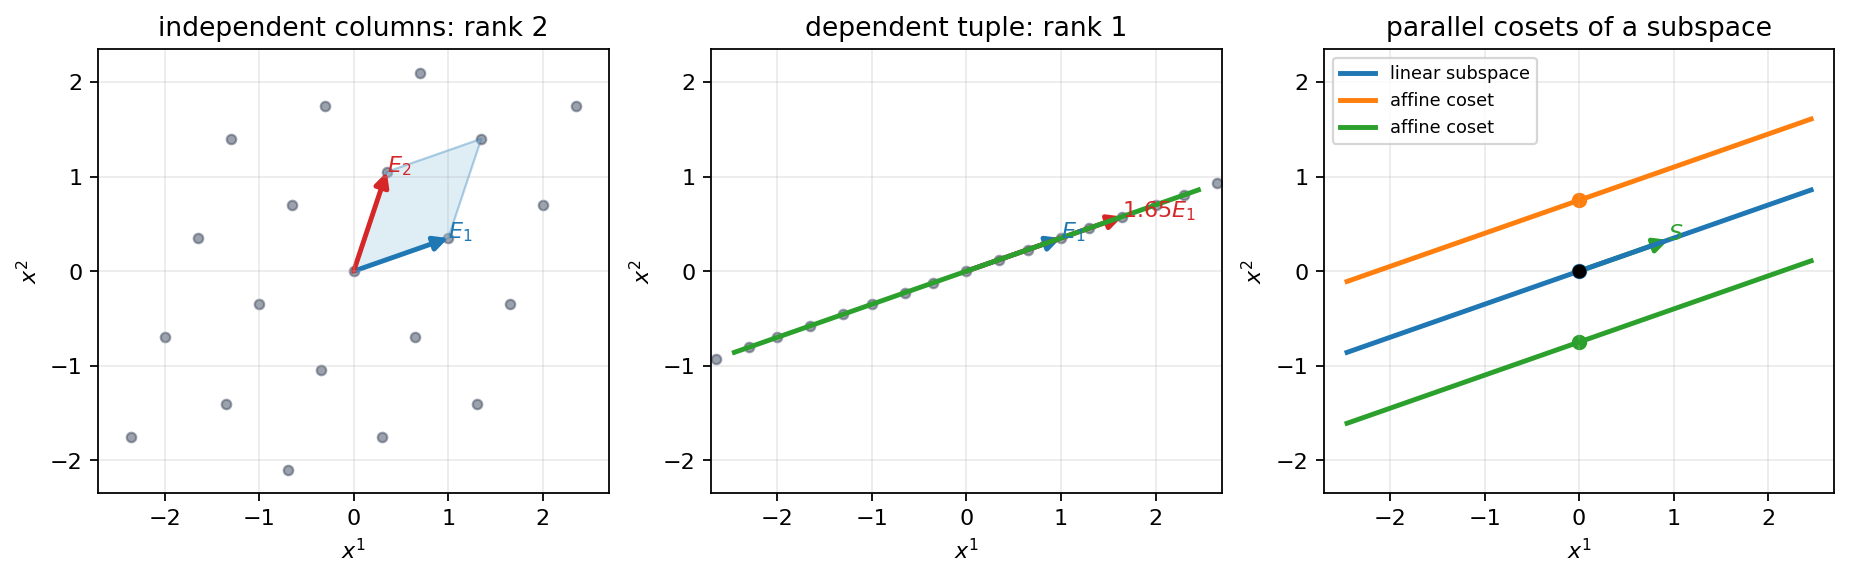

`appendix-b-span-basis-checks.json`

In [2]:
v1 = np.array([1.0, 0.35])
v2 = np.array([0.35, 1.05])
dep_v2 = 1.65 * v1
independent = np.column_stack([v1, v2])
dependent = np.column_stack([v1, dep_v2])

coeffs = np.arange(-2, 3)
grid_coeffs = np.array([(a, b) for a in coeffs for b in coeffs], dtype=float)
independent_points = grid_coeffs @ independent.T
dependent_points = grid_coeffs @ dependent.T

subspace_direction = v1 / np.linalg.norm(v1)
t = np.linspace(-2.6, 2.6, 100)
offsets = [np.array([0.0, 0.0]), np.array([0.0, 0.75]), np.array([0.0, -0.75])]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
colors = {"v1": "#1f77b4", "v2": "#d62728", "grid": "#4c566a"}

ax = axes[0]
ax.scatter(independent_points[:, 0], independent_points[:, 1], s=18, color=colors["grid"], alpha=0.55)
parallelogram = np.array([[0, 0], v1, v1 + v2, v2])
ax.add_patch(Polygon(parallelogram, closed=True, facecolor="#a6cee3", edgecolor="#1f77b4", alpha=0.35))
arrow(ax, [0, 0], v1, colors["v1"], "$E_1$")
arrow(ax, [0, 0], v2, colors["v2"], "$E_2$")
ax.set_title("independent columns: rank 2")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)

ax = axes[1]
ax.scatter(dependent_points[:, 0], dependent_points[:, 1], s=18, color=colors["grid"], alpha=0.55)
line = np.outer(t, subspace_direction)
ax.plot(line[:, 0], line[:, 1], color="#2ca02c", lw=2.2, label="span")
arrow(ax, [0, 0], v1, colors["v1"], "$E_1$")
arrow(ax, [0, 0], dep_v2, colors["v2"], "$1.65E_1$")
ax.set_title("dependent tuple: rank 1")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)

ax = axes[2]
for offset in offsets:
    coset = offset + np.outer(t, subspace_direction)
    label = "linear subspace" if np.allclose(offset, 0) else "affine coset"
    ax.plot(coset[:, 0], coset[:, 1], lw=2.2, label=label)
    ax.scatter([offset[0]], [offset[1]], s=35)
arrow(ax, [0, 0], subspace_direction, "#2ca02c", "$S$")
ax.scatter([0], [0], color="black", s=28, zorder=3)
ax.set_title("parallel cosets of a subspace")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", fontsize=8)

for ax in axes:
    ax.set_xlim(-2.7, 2.7)
    ax.set_ylim(-2.35, 2.35)
    ax.set_xlabel("$x^1$")
    ax.set_ylabel("$x^2$")

span_basis_path = save_matplotlib(fig, FIGURES / "appendix-b-span-basis-subspaces.png")
plt.close(fig)

span_checks = {
    "independent_rank": int(np.linalg.matrix_rank(independent)),
    "dependent_rank": int(np.linalg.matrix_rank(dependent)),
    "independent_determinant": float(np.linalg.det(independent)),
    "dependent_determinant": float(np.linalg.det(dependent)),
    "subspace_closure_residual": float(np.linalg.norm((1.7 * v1 - 0.4 * v1) - 1.3 * v1)),
    "coset_through_origin_is_linear": True,
    "shifted_coset_contains_origin": False,
}
assert span_checks["independent_rank"] == 2
assert span_checks["dependent_rank"] == 1
assert abs(span_checks["dependent_determinant"]) < 1e-12
span_check_path = save_json(span_checks, CHECKS / "appendix-b-span-basis-checks.json")

display_artifact(span_basis_path)
display_artifact(span_check_path)


## 2. Linear Maps, Kernel, Image, Isomorphism, Rank-Nullity

Once bases are chosen, a linear map is a matrix. Its image is the span of
the columns; its kernel is the set of coordinate vectors sent to zero. A
square map is an isomorphism exactly when the kernel is zero and the image
has full dimension.

The left side below shows a singular map on the domain grid. The kernel
line collapses to the origin, and all other grid points land on the
one-dimensional image line. The rank-nullity experiments on the right use
matrices with prescribed rank and check
`domain dimension = rank + nullity`.


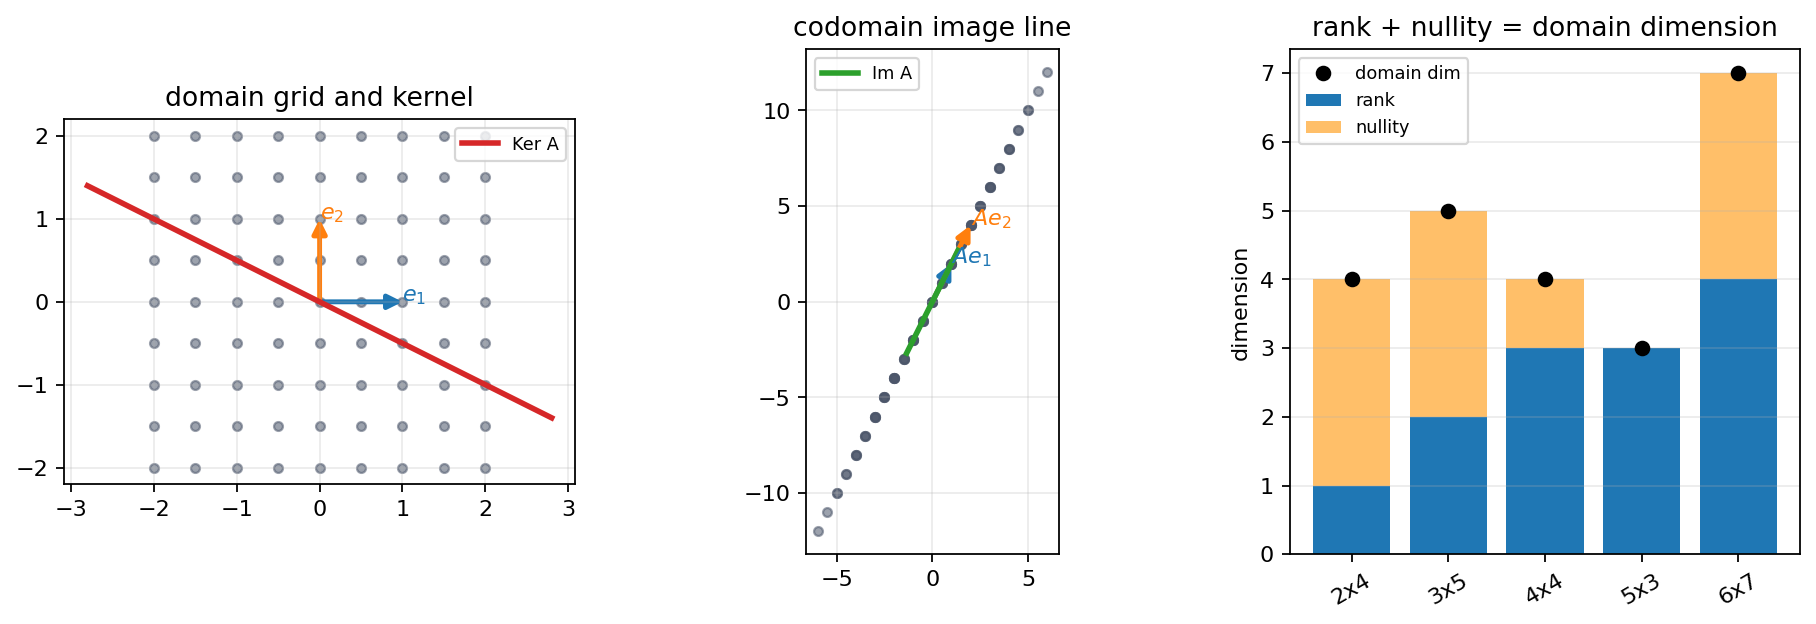

[appendix-b-rank-nullity-experiments.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/appendix-b-review-of-linear-algebra/tables/appendix-b-rank-nullity-experiments.csv)

`appendix-b-linear-map-rank-nullity.json`

In [3]:
A_singular = np.array([[1.0, 2.0], [2.0, 4.0]])
kernel_dir = np.array([-2.0, 1.0])
image_dir = A_singular[:, 0]

grid = np.linspace(-2, 2, 9)
domain_points = np.array([(x, y) for x in grid for y in grid])
image_points = domain_points @ A_singular.T

def prescribed_rank_matrix(m: int, n: int, r: int) -> np.ndarray:
    U, _ = np.linalg.qr(rng.normal(size=(m, m)))
    V, _ = np.linalg.qr(rng.normal(size=(n, n)))
    singular_values = np.linspace(4.0, 1.0, r)
    return U[:, :r] @ np.diag(singular_values) @ V[:, :r].T

rank_rows = []
experiments = [(2, 4, 1), (3, 5, 2), (4, 4, 3), (5, 3, 3), (6, 7, 4)]
for m, n, target_rank in experiments:
    M = prescribed_rank_matrix(m, n, target_rank)
    computed_rank = int(np.linalg.matrix_rank(M, tol=1e-9))
    nullity = n - computed_rank
    rank_rows.append(
        {
            "codomain_dim": m,
            "domain_dim": n,
            "target_rank": target_rank,
            "computed_rank": computed_rank,
            "nullity": nullity,
            "rank_plus_nullity": computed_rank + nullity,
        }
    )
rank_table = pd.DataFrame(rank_rows)
rank_table_path = save_csv(rank_rows, TABLES / "appendix-b-rank-nullity-experiments.csv")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))
ax = axes[0]
ax.scatter(domain_points[:, 0], domain_points[:, 1], s=16, color="#4c566a", alpha=0.55)
kline = np.outer(np.linspace(-1.4, 1.4, 100), kernel_dir)
ax.plot(kline[:, 0], kline[:, 1], color="#d62728", lw=2.5, label="Ker A")
arrow(ax, [0, 0], [1, 0], "#1f77b4", "$e_1$")
arrow(ax, [0, 0], [0, 1], "#ff7f0e", "$e_2$")
ax.set_title("domain grid and kernel")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(image_points[:, 0], image_points[:, 1], s=16, color="#4c566a", alpha=0.55)
iline = np.outer(np.linspace(-3.0, 3.0, 100), image_dir / np.linalg.norm(image_dir))
ax.plot(iline[:, 0], iline[:, 1], color="#2ca02c", lw=2.5, label="Im A")
arrow(ax, [0, 0], A_singular[:, 0], "#1f77b4", "$Ae_1$")
arrow(ax, [0, 0], A_singular[:, 1], "#ff7f0e", "$Ae_2$")
ax.set_title("codomain image line")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

ax = axes[2]
x = np.arange(len(rank_table))
ax.bar(x, rank_table["computed_rank"], label="rank", color="#1f77b4")
ax.bar(x, rank_table["nullity"], bottom=rank_table["computed_rank"], label="nullity", color="#ffbf69")
ax.plot(x, rank_table["domain_dim"], "ko", label="domain dim")
ax.set_xticks(x)
ax.set_xticklabels([f"{row.codomain_dim}x{row.domain_dim}" for row in rank_table.itertuples()], rotation=30)
ax.set_title("rank + nullity = domain dimension")
ax.set_ylabel("dimension")
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=8)

linear_map_path = save_matplotlib(fig, FIGURES / "appendix-b-kernel-image-rank-nullity.png")
plt.close(fig)

linear_checks = {
    "singular_map_rank": int(np.linalg.matrix_rank(A_singular)),
    "kernel_vector_residual": float(np.linalg.norm(A_singular @ kernel_dir)),
    "image_column_dependence_residual": float(np.linalg.norm(A_singular[:, 1] - 2 * A_singular[:, 0])),
    "rank_nullity_rows": rank_rows,
    "all_rank_nullity_identities_hold": bool(
        (rank_table["rank_plus_nullity"] == rank_table["domain_dim"]).all()
    ),
    "isomorphism_test_example": {
        "matrix": [[2.0, 1.0], [1.0, 1.0]],
        "determinant": float(np.linalg.det(np.array([[2.0, 1.0], [1.0, 1.0]]))),
        "kernel_zero_by_full_rank": True,
    },
}
assert linear_checks["singular_map_rank"] == 1
assert linear_checks["kernel_vector_residual"] < 1e-12
assert linear_checks["all_rank_nullity_identities_hold"]
linear_check_path = save_json(linear_checks, CHECKS / "appendix-b-linear-map-rank-nullity.json")

display_artifact(linear_map_path)
display_artifact(rank_table_path)
display_artifact(linear_check_path)


## 3. Matrices, Change of Basis, and Canonical Rank Form

A matrix is not just an array; it is the coordinate record of a linear map
after choosing ordered bases. If the same endomorphism is written in a new
basis, its matrix changes by a similarity transformation. Rank and
determinant do not change under this basis change.

For a map between different spaces, the canonical rank theorem allows
independent basis changes in the domain and codomain. The result is a
block matrix with an identity block of size equal to the rank and zeros
elsewhere. This is the coordinate version of splitting the domain into
preimages of the image plus the kernel.


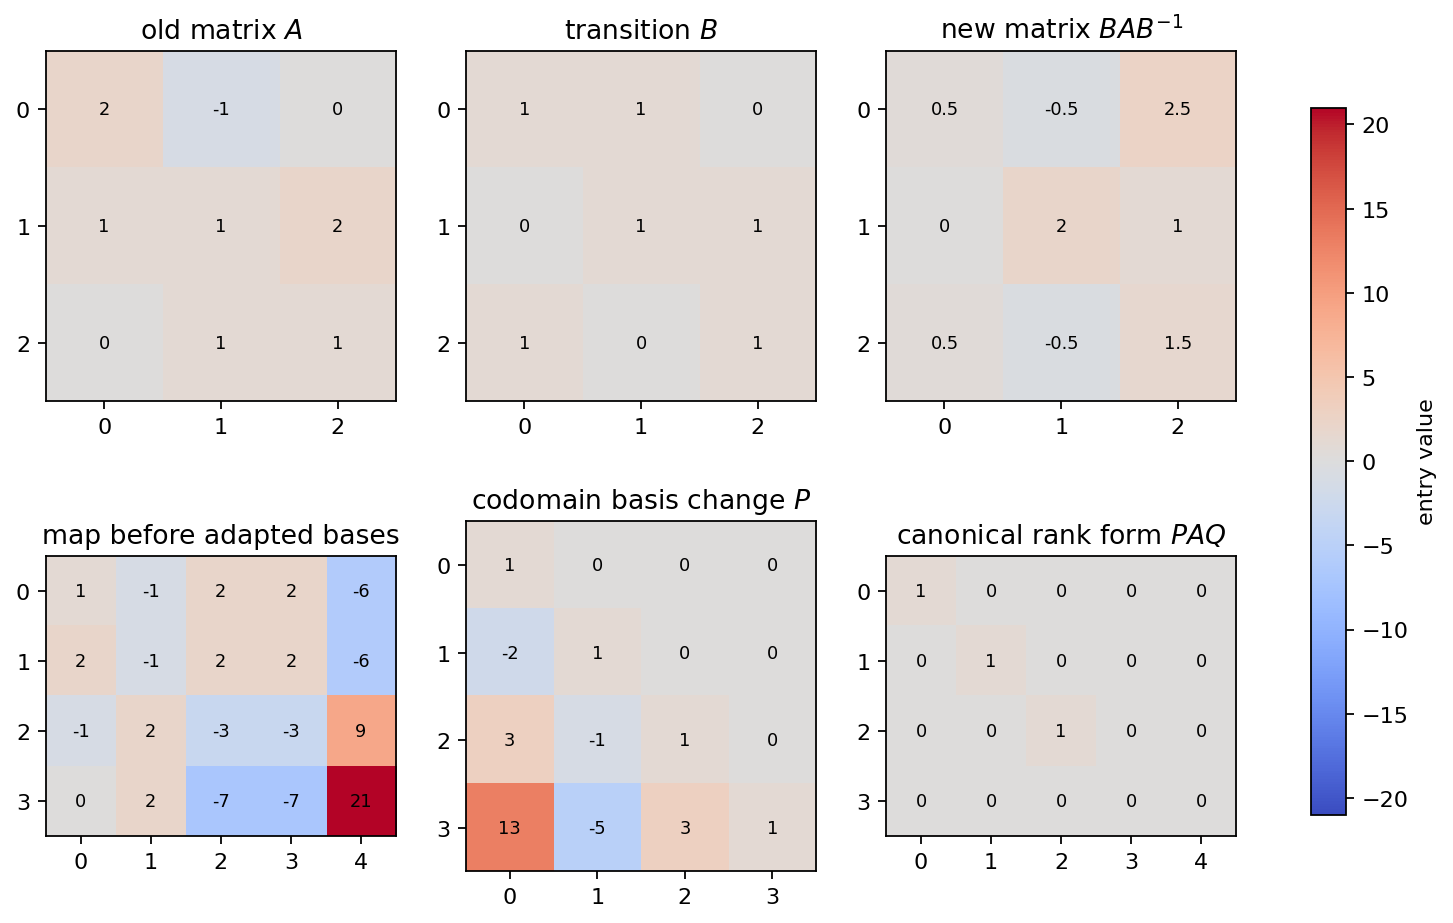

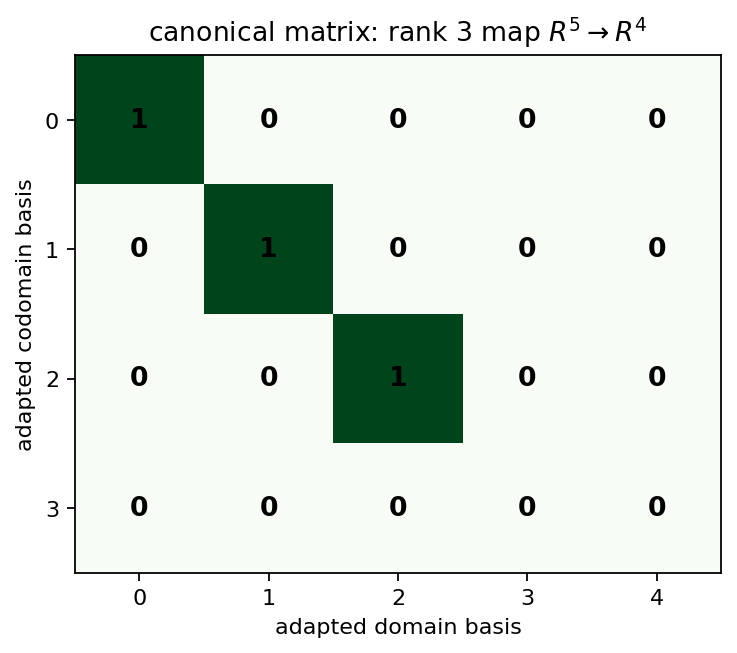

`appendix-b-change-of-basis-checks.json`

In [4]:
A_old = np.array([[2.0, -1.0, 0.0], [1.0, 1.0, 2.0], [0.0, 1.0, 1.0]])
B_transition = np.array([[1.0, 1.0, 0.0], [0.0, 1.0, 1.0], [1.0, 0.0, 1.0]])
A_new = B_transition @ A_old @ np.linalg.inv(B_transition)

U = sp.Matrix([[1, 0, 0, 0], [2, 1, 0, 0], [-1, 1, 1, 0], [0, 2, -3, 1]])
V = sp.Matrix(
    [
        [1, 1, 0, 0, 0],
        [0, 1, 2, 0, 0],
        [0, 0, 1, -1, 0],
        [0, 0, 0, 1, 3],
        [0, 0, 0, 0, 1],
    ]
)
J = sp.zeros(4, 5)
for i in range(3):
    J[i, i] = 1
A_exact = U * J * V.inv()
canonical = U.inv() * A_exact * V
A_exact_np = np.array(A_exact.tolist(), dtype=float)
canonical_np = np.array(canonical.tolist(), dtype=float)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
heatmaps = [
    (A_old, "old matrix $A$"),
    (B_transition, "transition $B$"),
    (A_new, "new matrix $BAB^{-1}$"),
    (A_exact_np, "map before adapted bases"),
    (np.array(U.inv().tolist(), dtype=float), "codomain basis change $P$"),
    (canonical_np, "canonical rank form $PAQ$"),
]
vmax = max(np.abs(M).max() for M, _ in heatmaps)
for ax, (M, title) in zip(axes.ravel(), heatmaps):
    im = ax.imshow(M, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
    for (i, j), value in np.ndenumerate(M):
        ax.text(j, i, f"{value:.0f}" if abs(value - round(value)) < 1e-9 else f"{value:.1f}",
                ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.82, label="entry value")
change_basis_path = save_matplotlib(fig, FIGURES / "appendix-b-change-of-basis-heatmaps.png")
plt.close(fig)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
im = ax.imshow(canonical_np, cmap="Greens", vmin=0, vmax=1)
ax.set_title("canonical matrix: rank 3 map $R^5 \\to R^4$")
ax.set_xlabel("adapted domain basis")
ax.set_ylabel("adapted codomain basis")
ax.set_xticks(range(5))
ax.set_yticks(range(4))
for (i, j), value in np.ndenumerate(canonical_np):
    ax.text(j, i, str(int(value)), ha="center", va="center", fontsize=12, weight="bold")
canonical_path = save_matplotlib(fig, FIGURES / "appendix-b-canonical-rank-form.png")
plt.close(fig)

change_checks = {
    "similarity_rank_old": int(np.linalg.matrix_rank(A_old)),
    "similarity_rank_new": int(np.linalg.matrix_rank(A_new)),
    "similarity_det_old": float(np.linalg.det(A_old)),
    "similarity_det_new": float(np.linalg.det(A_new)),
    "similarity_trace_old": float(np.trace(A_old)),
    "similarity_trace_new": float(np.trace(A_new)),
    "canonical_rank": int(A_exact.rank()),
    "domain_dimension": 5,
    "nullity": 5 - int(A_exact.rank()),
    "rank_plus_nullity": int(A_exact.rank()) + (5 - int(A_exact.rank())),
    "canonical_form_matches": bool(canonical == J),
}
assert change_checks["similarity_rank_old"] == change_checks["similarity_rank_new"]
assert abs(change_checks["similarity_det_old"] - change_checks["similarity_det_new"]) < 1e-9
assert abs(change_checks["similarity_trace_old"] - change_checks["similarity_trace_new"]) < 1e-9
assert change_checks["canonical_form_matches"]
assert change_checks["rank_plus_nullity"] == change_checks["domain_dimension"]
change_check_path = save_json(change_checks, CHECKS / "appendix-b-change-of-basis-checks.json")

display_artifact(change_basis_path)
display_artifact(canonical_path)
display_artifact(change_check_path)


## 4. Determinants: Orientation, Volume, and Identities

The determinant is an alternating volume measurement. In two dimensions it
gives signed area of the parallelogram spanned by the columns. In three
dimensions it gives signed volume. The sign records orientation, so a
determinant can distinguish a basis from its mirror image even when the
absolute volume is the same.

The exact checks below mirror the appendix identities: transpose does not
change the determinant, multiplication multiplies determinants, triangular
determinants are products of diagonal entries, and similarity preserves the
determinant of a linear endomorphism.


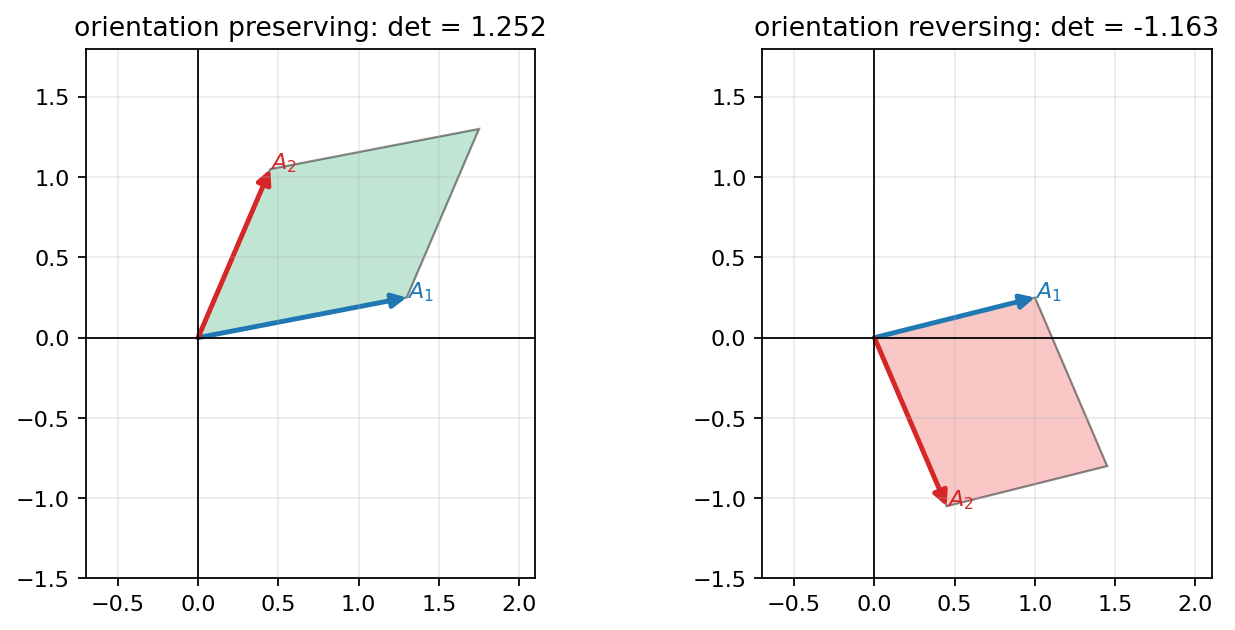

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


`appendix-b-determinant-identities.json`

In [5]:
A_pos = np.array([[1.3, 0.45], [0.25, 1.05]])
A_neg = np.array([[1.0, 0.45], [0.25, -1.05]])
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, M, title, color in [
    (axes[0], A_pos, "orientation preserving", "#74c69d"),
    (axes[1], A_neg, "orientation reversing", "#f28482"),
]:
    transformed = square @ M.T
    ax.add_patch(Polygon(transformed, closed=True, facecolor=color, edgecolor="black", alpha=0.45))
    arrow(ax, [0, 0], M[:, 0], "#1f77b4", "$A_1$")
    arrow(ax, [0, 0], M[:, 1], "#d62728", "$A_2$")
    det_value = np.linalg.det(M)
    ax.set_title(f"{title}: det = {det_value:.3f}")
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(-0.7, 2.1)
    ax.set_ylim(-1.5, 1.8)
determinant_area_path = save_matplotlib(fig, FIGURES / "appendix-b-determinant-orientation-area.png")
plt.close(fig)

M3 = np.array([[1.0, 0.25, 0.15], [0.35, 1.1, 0.35], [0.15, -0.2, 1.25]])
columns = [M3[:, i] for i in range(3)]
vertices = []
for bits in [(0, 0, 0), (1, 0, 0), (0, 1, 0), (0, 0, 1), (1, 1, 0), (1, 0, 1), (0, 1, 1), (1, 1, 1)]:
    vertices.append(sum(bits[i] * columns[i] for i in range(3)))
vertices = np.array(vertices)
edges = [(0, 1), (0, 2), (0, 3), (1, 4), (1, 5), (2, 4), (2, 6), (3, 5), (3, 6), (4, 7), (5, 7), (6, 7)]
fig3d = go.Figure()
for i, j in edges:
    fig3d.add_trace(
        go.Scatter3d(
            x=[vertices[i, 0], vertices[j, 0]],
            y=[vertices[i, 1], vertices[j, 1]],
            z=[vertices[i, 2], vertices[j, 2]],
            mode="lines",
            line=dict(color="#1f77b4", width=5),
            showlegend=False,
        )
    )
fig3d.add_trace(
    go.Scatter3d(
        x=[0, columns[0][0], columns[1][0], columns[2][0]],
        y=[0, columns[0][1], columns[1][1], columns[2][1]],
        z=[0, columns[0][2], columns[1][2], columns[2][2]],
        mode="markers+text",
        marker=dict(size=4, color=["black", "#1f77b4", "#d62728", "#2ca02c"]),
        text=["0", "A1", "A2", "A3"],
        textposition="top center",
        showlegend=False,
    )
)
fig3d.update_layout(
    title=f"3D parallelepiped volume |det A| = {abs(np.linalg.det(M3)):.4f}",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=0, r=0, t=45, b=0),
)
determinant_html_path = HTML / "appendix-b-determinant-volume-3d.html"
fig3d.write_html(str(determinant_html_path), include_plotlyjs="cdn", full_html=True)

A = sp.Matrix([[2, -1, 3], [0, 1, 4], [1, 2, 0]])
B = sp.Matrix([[1, 0, 2], [0, 1, -1], [1, 1, 2]])
T = sp.Matrix([[3, 2, -1], [0, -2, 5], [0, 0, 4]])
block = sp.Matrix([[2, 1, 3, 4], [0, 3, -1, 2], [0, 0, 5, 1], [0, 0, 0, -2]])
determinant_checks = {
    "det_A": int(A.det()),
    "det_transpose_equals": bool(A.det() == A.T.det()),
    "det_product_identity": bool((A * B).det() == A.det() * B.det()),
    "det_inverse_identity": sp.sstr((B.inv()).det() - 1 / B.det()),
    "det_similarity_identity": bool((B * A * B.inv()).det() == A.det()),
    "upper_triangular_diagonal_product": bool(T.det() == sp.prod(T[i, i] for i in range(T.shape[0]))),
    "block_upper_triangular_product": bool(block.det() == sp.Matrix([[2, 1], [0, 3]]).det() * sp.Matrix([[5, 1], [0, -2]]).det()),
    "area_positive": float(np.linalg.det(A_pos)),
    "area_negative": float(np.linalg.det(A_neg)),
    "volume_3d": float(np.linalg.det(M3)),
}
assert determinant_checks["det_transpose_equals"]
assert determinant_checks["det_product_identity"]
assert determinant_checks["det_similarity_identity"]
assert determinant_checks["upper_triangular_diagonal_product"]
assert determinant_checks["block_upper_triangular_product"]
determinant_check_path = save_json(determinant_checks, CHECKS / "appendix-b-determinant-identities.json")

display_artifact(determinant_area_path)
display_artifact(determinant_html_path, width=780, height=520)
display_artifact(determinant_check_path)


## 5. Inner Products, Gram-Schmidt, and Isometries

An inner product converts algebraic coordinates into geometry: lengths,
angles, orthogonality, and orthogonal projection. Gram-Schmidt takes an
arbitrary basis and produces an orthonormal basis without changing the
span of the first `k` input vectors at step `k`.

The check here is stronger than simply drawing perpendicular arrows. It
verifies the Gram matrix `Q^T Q`, prefix span preservation, and preservation
of lengths by the basis isomorphism determined by the orthonormal columns.


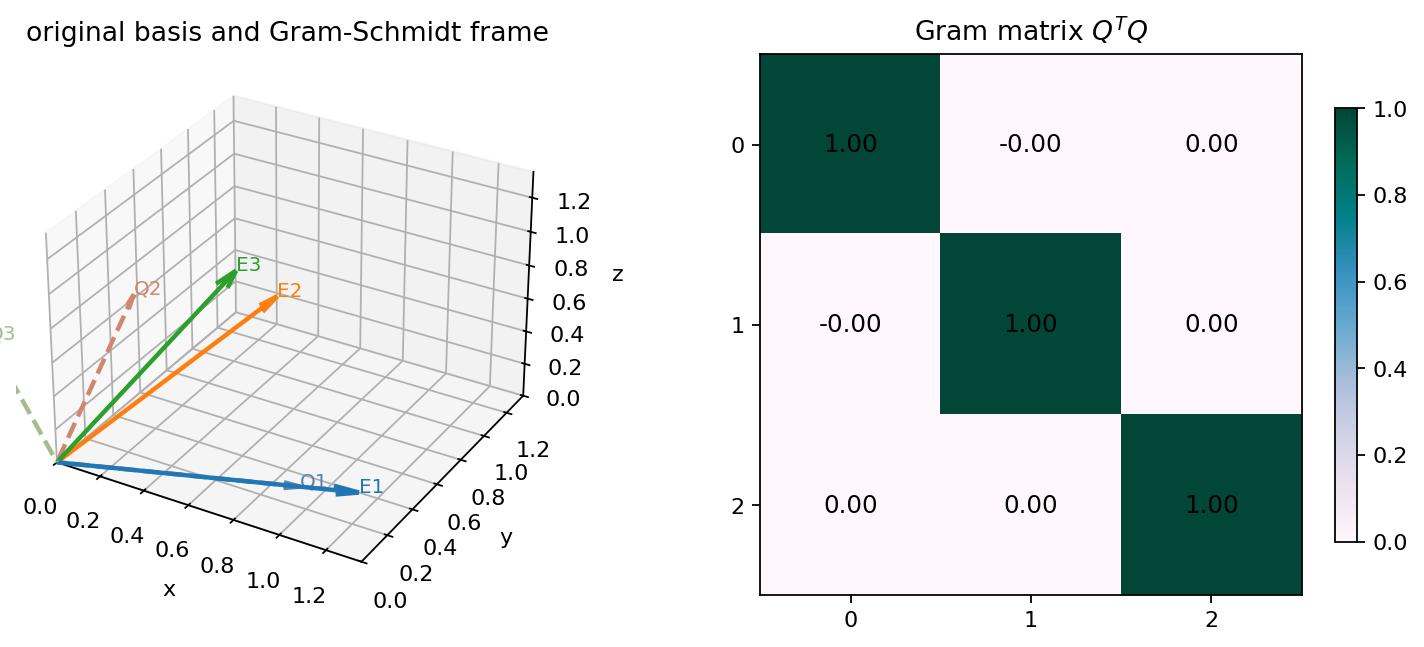

`appendix-b-gram-schmidt-isometry.json`

In [6]:
E = np.array(
    [
        [1.2, 0.35, 0.55],
        [0.25, 1.1, 0.45],
        [0.15, 0.4, 1.05],
    ]
)

def gram_schmidt_columns(A: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    Q_cols = []
    R = np.zeros((A.shape[1], A.shape[1]))
    for j in range(A.shape[1]):
        v = A[:, j].astype(float).copy()
        for i, q in enumerate(Q_cols):
            R[i, j] = float(q @ A[:, j])
            v = v - R[i, j] * q
        R[j, j] = np.linalg.norm(v)
        Q_cols.append(v / R[j, j])
    return np.column_stack(Q_cols), R

Q, R = gram_schmidt_columns(E)
gram_matrix = Q.T @ Q
random_coordinate = np.array([0.7, -1.2, 0.4])
isometry_residual = abs(np.linalg.norm(Q @ random_coordinate) - np.linalg.norm(random_coordinate))

prefix_rows = []
for k in range(1, 4):
    rank_E = np.linalg.matrix_rank(E[:, :k])
    rank_Q = np.linalg.matrix_rank(Q[:, :k])
    rank_combined = np.linalg.matrix_rank(np.column_stack([E[:, :k], Q[:, :k]]))
    prefix_rows.append(
        {
            "k": k,
            "rank_original_prefix": int(rank_E),
            "rank_orthonormal_prefix": int(rank_Q),
            "rank_combined_prefix": int(rank_combined),
            "same_span": bool(rank_combined == k),
        }
    )

fig = plt.figure(figsize=(12, 4.4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
colors_original = ["#1f77b4", "#ff7f0e", "#2ca02c"]
colors_orthonormal = ["#5e81ac", "#d08770", "#a3be8c"]
for i in range(3):
    ax.quiver(0, 0, 0, E[0, i], E[1, i], E[2, i], color=colors_original[i], linewidth=2, arrow_length_ratio=0.08)
    ax.text(E[0, i], E[1, i], E[2, i], f"E{i+1}", color=colors_original[i], fontsize=9)
    ax.quiver(0, 0, 0, Q[0, i], Q[1, i], Q[2, i], color=colors_orthonormal[i], linestyle="dashed", linewidth=2, arrow_length_ratio=0.08)
    ax.text(Q[0, i], Q[1, i], Q[2, i], f"Q{i+1}", color=colors_orthonormal[i], fontsize=9)
ax.set_title("original basis and Gram-Schmidt frame")
ax.set_xlim(0, 1.35)
ax.set_ylim(0, 1.35)
ax.set_zlim(0, 1.35)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax = fig.add_subplot(1, 2, 2)
im = ax.imshow(gram_matrix, cmap="PuBuGn", vmin=0, vmax=1)
for (i, j), value in np.ndenumerate(gram_matrix):
    ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=11)
ax.set_title("Gram matrix $Q^TQ$")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
fig.colorbar(im, ax=ax, shrink=0.8)
gram_schmidt_path = save_matplotlib(fig, FIGURES / "appendix-b-gram-schmidt-isometry.png")
plt.close(fig)

gram_checks = {
    "max_off_diagonal_abs": float(np.max(np.abs(gram_matrix - np.eye(3)))),
    "prefix_span_rows": prefix_rows,
    "reconstruction_residual": float(np.linalg.norm(E - Q @ R)),
    "isometry_length_residual": float(isometry_residual),
    "R_upper_triangular": bool(np.allclose(R, np.triu(R))),
}
assert gram_checks["max_off_diagonal_abs"] < 1e-12
assert all(row["same_span"] for row in prefix_rows)
assert gram_checks["reconstruction_residual"] < 1e-12
assert gram_checks["isometry_length_residual"] < 1e-12
gram_check_path = save_json(gram_checks, CHECKS / "appendix-b-gram-schmidt-isometry.json")

display_artifact(gram_schmidt_path)
display_artifact(gram_check_path)


## 6. Norms and Equivalent Finite-Dimensional Topologies

A norm supplies distances and hence a topology. In finite-dimensional
vector spaces, different norms can distort shape but cannot change which
sequences converge or which sets are open. Geometrically, each unit ball
fits between scaled copies of every other unit ball.

The picture compares four unit balls in `R^2`: `l1`, Euclidean `l2`,
`l_infinity`, and a norm induced by a positive definite Gram matrix. The
sampled checks record explicit comparison constants.


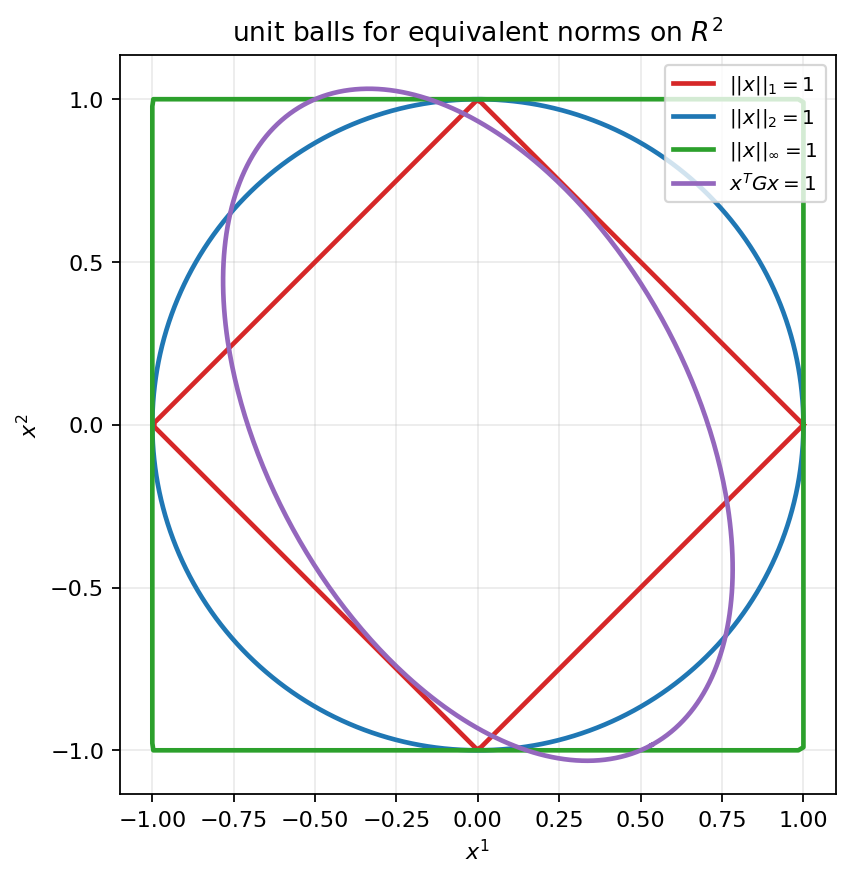

[appendix-b-norm-comparison-samples.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/appendix-b-review-of-linear-algebra/tables/appendix-b-norm-comparison-samples.csv)

`appendix-b-norm-equivalence.json`

In [7]:
theta = np.linspace(0, 2 * np.pi, 500)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
l1_ball = np.column_stack([np.cos(theta), np.sin(theta)]) / (
    np.abs(np.cos(theta)) + np.abs(np.sin(theta))
)[:, None]
linf_ball = np.column_stack([np.cos(theta), np.sin(theta)]) / (
    np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta)))
)[:, None]
G = np.array([[2.0, 0.65], [0.65, 1.15]])
eigvals, eigvecs = np.linalg.eigh(G)
ellipse = eigvecs @ np.diag(1 / np.sqrt(eigvals)) @ circle.T
ellipse = ellipse.T

samples = rng.normal(size=(2000, 2))
norm2 = np.linalg.norm(samples, axis=1)
norm1 = np.linalg.norm(samples, ord=1, axis=1)
norminf = np.linalg.norm(samples, ord=np.inf, axis=1)
normG = np.sqrt(np.einsum("bi,ij,bj->b", samples, G, samples))
norm_rows = [
    {
        "inequality": "||x||_inf <= ||x||_2",
        "max_violation": float(np.max(norminf - norm2)),
        "constant": 1.0,
    },
    {
        "inequality": "||x||_2 <= sqrt(2)||x||_inf",
        "max_violation": float(np.max(norm2 - math.sqrt(2) * norminf)),
        "constant": math.sqrt(2),
    },
    {
        "inequality": "(1/sqrt(2))||x||_1 <= ||x||_2",
        "max_violation": float(np.max((1 / math.sqrt(2)) * norm1 - norm2)),
        "constant": 1 / math.sqrt(2),
    },
    {
        "inequality": "||x||_2 <= ||x||_1",
        "max_violation": float(np.max(norm2 - norm1)),
        "constant": 1.0,
    },
    {
        "inequality": "sqrt(lambda_min)||x||_2 <= ||x||_G",
        "max_violation": float(np.max(math.sqrt(eigvals.min()) * norm2 - normG)),
        "constant": float(math.sqrt(eigvals.min())),
    },
    {
        "inequality": "||x||_G <= sqrt(lambda_max)||x||_2",
        "max_violation": float(np.max(normG - math.sqrt(eigvals.max()) * norm2)),
        "constant": float(math.sqrt(eigvals.max())),
    },
]
norm_table_path = save_csv(norm_rows, TABLES / "appendix-b-norm-comparison-samples.csv")

fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.plot(l1_ball[:, 0], l1_ball[:, 1], label="$||x||_1=1$", color="#d62728", lw=2.1)
ax.plot(circle[:, 0], circle[:, 1], label="$||x||_2=1$", color="#1f77b4", lw=2.1)
ax.plot(linf_ball[:, 0], linf_ball[:, 1], label="$||x||_\\infty=1$", color="#2ca02c", lw=2.1)
ax.plot(ellipse[:, 0], ellipse[:, 1], label="$x^TGx=1$", color="#9467bd", lw=2.1)
ax.set_title("unit balls for equivalent norms on $R^2$")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=9)
ax.set_xlabel("$x^1$")
ax.set_ylabel("$x^2$")
norm_path = save_matplotlib(fig, FIGURES / "appendix-b-norm-unit-balls.png")
plt.close(fig)

norm_checks = {
    "G_eigenvalues": [float(v) for v in eigvals],
    "positive_definite_G": bool(np.all(eigvals > 0)),
    "sample_size": int(samples.shape[0]),
    "max_sampled_violation": float(max(row["max_violation"] for row in norm_rows)),
    "all_sampled_inequalities_hold_with_tolerance": bool(
        max(row["max_violation"] for row in norm_rows) < 1e-12
    ),
}
assert norm_checks["positive_definite_G"]
assert norm_checks["all_sampled_inequalities_hold_with_tolerance"]
norm_check_path = save_json(norm_checks, CHECKS / "appendix-b-norm-equivalence.json")

display_artifact(norm_path)
display_artifact(norm_table_path)
display_artifact(norm_check_path)


## 7. Direct Products, Direct Sums, Modules, and Hom

Direct products and direct sums are easiest to remember by their arrows.
A map into a product is the same thing as a compatible family of maps into
each factor. A map out of a direct sum is the same thing as a family of
maps out of each summand. In a finite family the underlying tuples agree,
but the characteristic properties point in opposite directions.

The appendix states these facts for modules over a commutative ring. The
checks below use block matrices over the integers, so the same formulas
can be read either as real-linear maps or as homomorphisms of free
`Z`-modules. The final check is the canonical isomorphism
`Hom_R( direct sum V_alpha, W )` with the product of the `Hom_R(V_alpha,W)`.


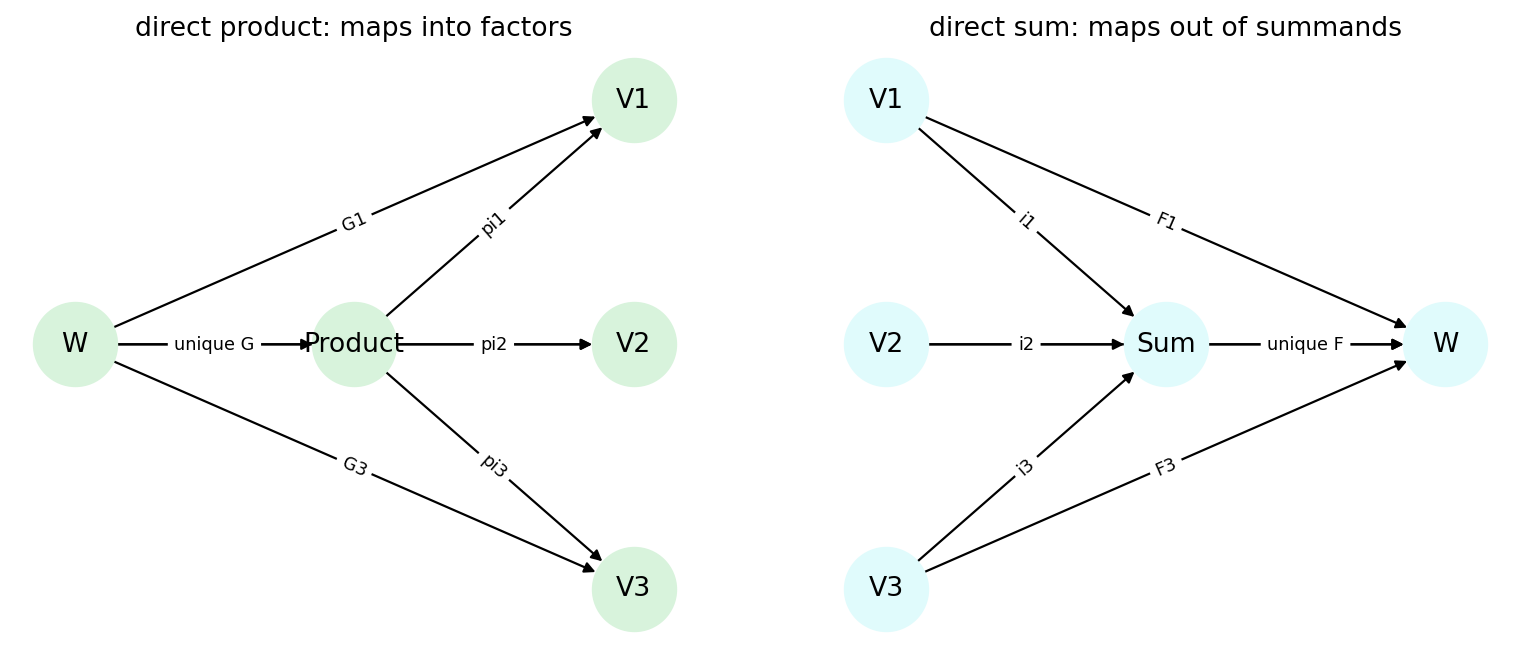

`appendix-b-direct-sum-product-hom.json`

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

product_graph = nx.DiGraph()
product_graph.add_edges_from(
    [
        ("W", "Product"),
        ("Product", "V1"),
        ("Product", "V2"),
        ("Product", "V3"),
        ("W", "V1"),
        ("W", "V2"),
        ("W", "V3"),
    ]
)
product_pos = {"W": (0, 1), "Product": (1.2, 1), "V1": (2.4, 1.8), "V2": (2.4, 1.0), "V3": (2.4, 0.2)}
nx.draw_networkx(product_graph, product_pos, ax=axes[0], node_color="#d8f3dc", node_size=1400, arrows=True)
nx.draw_networkx_edge_labels(
    product_graph,
    product_pos,
    edge_labels={
        ("W", "Product"): "unique G",
        ("Product", "V1"): "pi1",
        ("Product", "V2"): "pi2",
        ("Product", "V3"): "pi3",
        ("W", "V1"): "G1",
        ("W", "V2"): "G2",
        ("W", "V3"): "G3",
    },
    ax=axes[0],
    font_size=8,
)
axes[0].set_title("direct product: maps into factors")
axes[0].axis("off")

sum_graph = nx.DiGraph()
sum_graph.add_edges_from(
    [
        ("V1", "Sum"),
        ("V2", "Sum"),
        ("V3", "Sum"),
        ("Sum", "W"),
        ("V1", "W"),
        ("V2", "W"),
        ("V3", "W"),
    ]
)
sum_pos = {"V1": (0, 1.8), "V2": (0, 1.0), "V3": (0, 0.2), "Sum": (1.2, 1), "W": (2.4, 1)}
nx.draw_networkx(sum_graph, sum_pos, ax=axes[1], node_color="#e0fbfc", node_size=1400, arrows=True)
nx.draw_networkx_edge_labels(
    sum_graph,
    sum_pos,
    edge_labels={
        ("V1", "Sum"): "i1",
        ("V2", "Sum"): "i2",
        ("V3", "Sum"): "i3",
        ("Sum", "W"): "unique F",
        ("V1", "W"): "F1",
        ("V2", "W"): "F2",
        ("V3", "W"): "F3",
    },
    ax=axes[1],
    font_size=8,
)
axes[1].set_title("direct sum: maps out of summands")
axes[1].axis("off")

universal_path = save_matplotlib(fig, FIGURES / "appendix-b-direct-sum-product-universal-properties.png")
plt.close(fig)

# Product universal property: W = Z^2, V1 = Z, V2 = Z^2, V3 = Z.
G1 = sp.Matrix([[2, -1]])
G2 = sp.Matrix([[1, 0], [3, 2]])
G3 = sp.Matrix([[-4, 5]])
G_product = sp.Matrix.vstack(G1, G2, G3)
P1 = sp.Matrix([[1, 0, 0, 0]])
P2 = sp.Matrix([[0, 1, 0, 0], [0, 0, 1, 0]])
P3 = sp.Matrix([[0, 0, 0, 1]])

# Direct sum universal property: V1 = Z, V2 = Z^2, V3 = Z, W = Z^2.
F1 = sp.Matrix([[1], [2]])
F2 = sp.Matrix([[0, 3], [-1, 4]])
F3 = sp.Matrix([[5], [0]])
F_sum = sp.Matrix.hstack(F1, F2, F3)
I1 = sp.Matrix([[1], [0], [0], [0]])
I2 = sp.Matrix([[0, 0], [1, 0], [0, 1], [0, 0]])
I3 = sp.Matrix([[0], [0], [0], [1]])

dims = [1, 2, 1]
wdim = 2
hom_dim_left = wdim * sum(dims)
hom_dim_right = sum(wdim * d for d in dims)
finite_support_example = {0: 2, 3: -1, 8: 5}
finite_support_size = sum(1 for value in finite_support_example.values() if value != 0)

universal_checks = {
    "product_projection_1": bool(P1 * G_product == G1),
    "product_projection_2": bool(P2 * G_product == G2),
    "product_projection_3": bool(P3 * G_product == G3),
    "direct_sum_inclusion_1": bool(F_sum * I1 == F1),
    "direct_sum_inclusion_2": bool(F_sum * I2 == F2),
    "direct_sum_inclusion_3": bool(F_sum * I3 == F3),
    "hom_dimension_left": hom_dim_left,
    "hom_dimension_right": hom_dim_right,
    "hom_dimensions_match": bool(hom_dim_left == hom_dim_right),
    "finite_support_nonzero_components": finite_support_size,
    "finite_support_example_is_valid_direct_sum_element": bool(finite_support_size < math.inf),
}
assert universal_checks["product_projection_1"]
assert universal_checks["product_projection_2"]
assert universal_checks["product_projection_3"]
assert universal_checks["direct_sum_inclusion_1"]
assert universal_checks["direct_sum_inclusion_2"]
assert universal_checks["direct_sum_inclusion_3"]
assert universal_checks["hom_dimensions_match"]
universal_check_path = save_json(universal_checks, CHECKS / "appendix-b-direct-sum-product-hom.json")

display_artifact(universal_path)
display_artifact(universal_check_path)


## Applied Lab: A Family that Loses Rank

Smooth manifold arguments repeatedly ask whether a derivative has constant
rank. Appendix B supplies the linear algebra behind that question. This
small family tracks a matrix `A(t)` whose determinant and rank change at
one parameter value. Away from the exceptional value, the map is an
isomorphism of `R^3`; at the exceptional value its kernel becomes
one-dimensional.


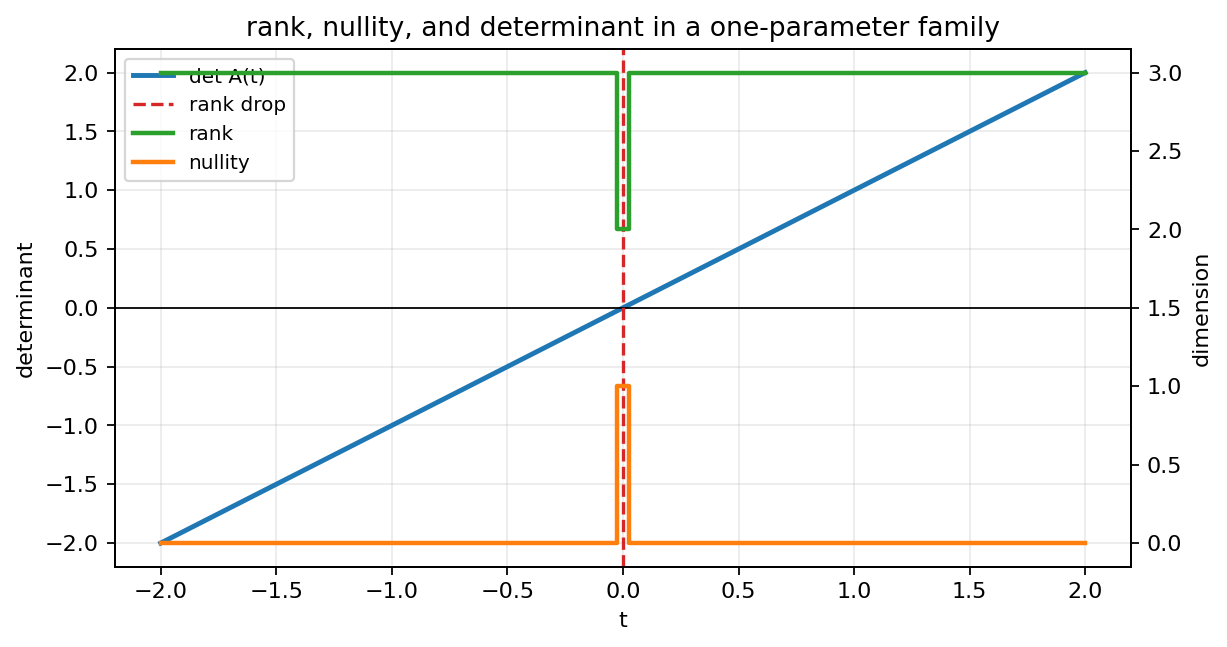

[appendix-b-rank-drop-family.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/appendix-b-review-of-linear-algebra/tables/appendix-b-rank-drop-family.csv)

`appendix-b-applied-lab-rank-drop-family.json`

In [9]:
t_values = np.linspace(-2.0, 2.0, 81)

def A_family(t_value: float) -> np.ndarray:
    return np.array([[1.0, 0.0, 1.0], [0.0, 1.0, -1.0], [0.0, 0.0, t_value]])

lab_rows = []
for t_value in t_values:
    M = A_family(t_value)
    rank = int(np.linalg.matrix_rank(M, tol=1e-10))
    lab_rows.append(
        {
            "t": float(t_value),
            "determinant": float(np.linalg.det(M)),
            "rank": rank,
            "nullity": int(3 - rank),
            "is_isomorphism": bool(rank == 3),
        }
    )
lab_table = pd.DataFrame(lab_rows)
lab_table_path = save_csv(lab_rows, TABLES / "appendix-b-rank-drop-family.csv")

fig, ax1 = plt.subplots(figsize=(8.2, 4.2))
ax1.plot(lab_table["t"], lab_table["determinant"], color="#1f77b4", lw=2.2, label="det A(t)")
ax1.axhline(0, color="black", lw=0.8)
ax1.axvline(0, color="#d62728", lw=1.5, linestyle="--", label="rank drop")
ax1.set_xlabel("t")
ax1.set_ylabel("determinant")
ax2 = ax1.twinx()
ax2.step(lab_table["t"], lab_table["rank"], where="mid", color="#2ca02c", lw=2.0, label="rank")
ax2.step(lab_table["t"], lab_table["nullity"], where="mid", color="#ff7f0e", lw=2.0, label="nullity")
ax2.set_ylabel("dimension")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=9)
ax1.set_title("rank, nullity, and determinant in a one-parameter family")
ax1.grid(True, alpha=0.25)
lab_path = save_matplotlib(fig, FIGURES / "appendix-b-applied-lab-rank-drop-family.png")
plt.close(fig)

zero_row = lab_table.loc[np.isclose(lab_table["t"], 0.0)].iloc[0]
lab_checks = {
    "rank_at_zero": int(zero_row["rank"]),
    "nullity_at_zero": int(zero_row["nullity"]),
    "rank_away_from_zero_min": int(lab_table.loc[~np.isclose(lab_table["t"], 0.0), "rank"].min()),
    "rank_nullity_identity_all_rows": bool(((lab_table["rank"] + lab_table["nullity"]) == 3).all()),
    "determinant_equals_parameter_max_error": float(np.max(np.abs(lab_table["determinant"] - lab_table["t"]))),
}
assert lab_checks["rank_at_zero"] == 2
assert lab_checks["nullity_at_zero"] == 1
assert lab_checks["rank_away_from_zero_min"] == 3
assert lab_checks["rank_nullity_identity_all_rows"]
assert lab_checks["determinant_equals_parameter_max_error"] < 1e-12
lab_check_path = save_json(lab_checks, CHECKS / "appendix-b-applied-lab-rank-drop-family.json")

display_artifact(lab_path)
display_artifact(lab_table_path)
display_artifact(lab_check_path)


## Final Sanity Checks

A notebook for a review appendix should not stop at definitions. The final
checks gather the core invariants that make the later manifold arguments
reliable: ranks match spans, kernels account for missing dimensions,
determinants obey their identities, Gram-Schmidt preserves spans, norm
comparisons have explicit constants, and universal-property diagrams
commute as block-matrix equations.


In [10]:
expected_artifacts = [
    routing_path,
    storyboard_path,
    span_basis_path,
    span_check_path,
    linear_map_path,
    rank_table_path,
    linear_check_path,
    change_basis_path,
    canonical_path,
    change_check_path,
    determinant_area_path,
    determinant_html_path,
    determinant_check_path,
    gram_schmidt_path,
    gram_check_path,
    norm_path,
    norm_table_path,
    norm_check_path,
    universal_path,
    universal_check_path,
    lab_path,
    lab_table_path,
    lab_check_path,
]
assert_artifacts(expected_artifacts, min_bytes=80)

final_checks = {
    "artifact_count": len(expected_artifacts),
    "artifacts": [rel(path) for path in expected_artifacts],
    "rank_nullity_experiments_ok": linear_checks["all_rank_nullity_identities_hold"],
    "canonical_rank_form_ok": change_checks["canonical_form_matches"],
    "determinant_identities_ok": all(
        [
            determinant_checks["det_transpose_equals"],
            determinant_checks["det_product_identity"],
            determinant_checks["det_similarity_identity"],
            determinant_checks["upper_triangular_diagonal_product"],
            determinant_checks["block_upper_triangular_product"],
        ]
    ),
    "gram_schmidt_ok": gram_checks["max_off_diagonal_abs"] < 1e-12
    and all(row["same_span"] for row in gram_checks["prefix_span_rows"]),
    "norm_equivalence_ok": norm_checks["all_sampled_inequalities_hold_with_tolerance"],
    "universal_properties_ok": all(
        [
            universal_checks["product_projection_1"],
            universal_checks["product_projection_2"],
            universal_checks["product_projection_3"],
            universal_checks["direct_sum_inclusion_1"],
            universal_checks["direct_sum_inclusion_2"],
            universal_checks["direct_sum_inclusion_3"],
            universal_checks["hom_dimensions_match"],
        ]
    ),
    "applied_lab_ok": lab_checks["rank_nullity_identity_all_rows"]
    and lab_checks["rank_at_zero"] == 2
    and lab_checks["rank_away_from_zero_min"] == 3,
}
assert final_checks["rank_nullity_experiments_ok"]
assert final_checks["canonical_rank_form_ok"]
assert final_checks["determinant_identities_ok"]
assert final_checks["gram_schmidt_ok"]
assert final_checks["norm_equivalence_ok"]
assert final_checks["universal_properties_ok"]
assert final_checks["applied_lab_ok"]
final_sanity_path = save_json(final_checks, CHECKS / "appendix-b-final-sanity.json")
display_artifact(final_sanity_path)
final_checks


`appendix-b-final-sanity.json`

{'artifact_count': 23,
 'artifacts': ['artifacts/appendix-b-review-of-linear-algebra/tables/appendix-b-library-routing.csv',
  'artifacts/appendix-b-review-of-linear-algebra/checks/appendix-b-visual-storyboard.json',
  'artifacts/appendix-b-review-of-linear-algebra/figures/appendix-b-span-basis-subspaces.png',
  'artifacts/appendix-b-review-of-linear-algebra/checks/appendix-b-span-basis-checks.json',
  'artifacts/appendix-b-review-of-linear-algebra/figures/appendix-b-kernel-image-rank-nullity.png',
  'artifacts/appendix-b-review-of-linear-algebra/tables/appendix-b-rank-nullity-experiments.csv',
  'artifacts/appendix-b-review-of-linear-algebra/checks/appendix-b-linear-map-rank-nullity.json',
  'artifacts/appendix-b-review-of-linear-algebra/figures/appendix-b-change-of-basis-heatmaps.png',
  'artifacts/appendix-b-review-of-linear-algebra/figures/appendix-b-canonical-rank-form.png',
  'artifacts/appendix-b-review-of-linear-algebra/checks/appendix-b-change-of-basis-checks.json',
  'artifac

## Takeaways

- Ordered bases convert vector-space questions into coordinate algebra,
  but the invariant information is rank, dimension, determinant, and the
  relevant universal property.
- The kernel-image split explains both canonical rank form and
  rank-nullity.
- Determinants are coordinate-independent for endomorphisms because
  similarity does not change them.
- Gram-Schmidt is the finite-dimensional bridge from arbitrary bases to
  orthonormal frames and linear isometries.
- Equivalent finite-dimensional norms can look geometrically different
  while producing the same topology.
- Direct products and direct sums are not just constructions of tuples:
  their projection and injection diagrams are the data used later in
  cohomology and Hom computations.
